# autouq on autosim toys — calibrated UQ against closed-form oracles

**Stage 1 of two.** Before validating uncertainty quantification (UQ) on the large
64×64 multi-channel field run, we prove the autouq calibrators on the *stochastic
toy* simulators from autosim (`autosim.experimental.simulations`). Each toy exposes a
**closed-form oracle** for its true predictive distribution, so we can check a
calibrated forecast against the *exact* answer — not just empirical coverage.

Every forecaster here is **genuinely fitted on a training split** — we do *not*
hand-pick a mis-specified simulator. We learn the mean dynamics from `train`
(an AR(1) fit, a least-squares linear operator, an MLP tendency emulator) and dress
it with a **rescaled bootstrap of its own training residuals**. The rescale `S < 1`
makes the ensemble **under-dispersed** — the ubiquitous failure of real ensemble
emulators — and autouq recalibrates it back toward the oracle.

We judge every calibrator on **four axes**, because a single coverage number hides
too much (a uselessly wide interval still "covers"; and marginal metrics are *blind*
to spatial dependence):

1. **Calibration** — is the stated probability honest? *reliability diagram, rank
   histogram, spread–skill ratio, coverage.*
2. **Sharpness** — as tight as possible given calibration? *interval width, CRPS, and
   the **Winkler / interval score** that penalises width and misses together.*
3. **Dependence** — is the joint structure right? *covariance recovery vs the oracle,
   variance of a spatial aggregate, correlation maps.* CRPS — and even the
   multivariate *energy score* — are near-blind here; ECC needs a dependence-specific
   metric.
4. **Distance-to-truth** — unique to these toys. *calibrated variance/covariance vs
   the closed-form oracle.*

**Three data splits** (independent seeded draws → exchangeable): `train` (fits the
forecaster) · `cal` holdout (fits the calibrators) · `test` out-of-sample (evaluated
once).

| toy | axis | oracle | fitted forecaster | headline conclusion |
|---|---|---|---|---|
| **Ornstein–Uhlenbeck** | temporal rollout | exact Gaussian variance | AR(1) fit + residual bootstrap | Gaussian ⇒ **EMOS** is best |
| **CorrelatedDiffusion2D** | spatial field | closed-form covariance | least-squares operator + residual-**field** bootstrap | dependence ⇒ **EMOS+ECC** |
| **Lorenz-96** | chaotic | Monte-Carlo | MLP tendency + residual bootstrap | non-Gaussian ⇒ **conformal** |

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from autosim.experimental.simulations import OrnsteinUhlenbeck, CorrelatedDiffusion2D, Lorenz96
from autosim.experimental.simulations.ornstein_uhlenbeck import ou_closed_form_var
from autouq.calibrators.emos import EMOS, EMOSECC
from autouq.calibrators.conformal import Ensemble
from autocast.metrics.ensemble import CRPS, EnergyScore, VariogramScore, SpreadSkillRatio
try:
    from autouq.calibrators import AxisRole
except ImportError:
    from autouq.calibrators.grouping import AxisRole

torch.manual_seed(0)
ALPHA, NOMINAL, Z = 0.1, 0.9, 1.6448536
LEVELS = np.round(np.arange(0.1, 0.91, 0.1), 2)      # nominal coverages for reliability

# ---- shared evaluation helpers ----
def rel_ens(true, ens, levels=LEVELS):
    "observed coverage of an ENSEMBLE's central intervals at each nominal level"
    out = []
    for L in levels:
        a = 1 - L
        lo, hi = torch.quantile(ens, torch.tensor([a / 2, 1 - a / 2], dtype=ens.dtype), dim=-1)
        out.append(((true >= lo) & (true <= hi)).float().mean().item())
    return np.array(out)

def rel_cal(true, cal, pred, levels=LEVELS):
    "observed coverage of a CALIBRATOR's predicted intervals at each nominal level"
    iv = cal.predict(pred, alphas=[float(1 - L) for L in levels])
    return np.array([((true >= iv[..., 0, i]) & (true <= iv[..., 1, i])).float().mean().item()
                     for i in range(len(levels))])

def rank_hist(true, ens):
    "Talagrand rank histogram counts over M+1 bins; flat = calibrated"
    r = (ens < true.unsqueeze(-1)).sum(-1).flatten()
    return torch.bincount(r, minlength=ens.shape[-1] + 1).float().numpy()

def per_lead(metric, ens, true):
    "reduce a BTSCM metric (score_dims='spatial') to a per-lead (T,) curve"
    return metric.score(ens, true).mean(dim=(0, 2)).detach().numpy()

def winkler(true, lo, hi, alpha=ALPHA):
    "mean Winkler / interval score: width + miss penalty (lower=better)"
    return ((hi - lo)
            + (2 / alpha) * torch.clamp(lo - true, min=0)
            + (2 / alpha) * torch.clamp(true - hi, min=0)).mean().item()

def reliab_ax(ax, curves, title):
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    for lbl, y in curves.items():
        ax.plot(LEVELS, y, "o-", ms=3, label=lbl)
    ax.set(xlabel="nominal coverage", ylabel="observed", title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend(fontsize=8); ax.set_aspect("equal")

print("nominal", NOMINAL, "| reliability levels", LEVELS)

nominal 0.9 | reliability levels [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


## Toy 1 — Ornstein–Uhlenbeck: the temporal multi-step-rollout fix

The exact AR(1) `x_{t+1} = a x_t + kappa m dt + c √dt ξ`, whose n-step predictive is
Gaussian with the closed-form variance `ou_closed_form_var`. We **fit** the AR(1)
coefficients `(a, b)` from `train` one-step pairs by least squares, then roll the
forecast forward from each initial condition, dressing every step with a **rescaled
bootstrap of the fitted residuals** (`S = 0.6` ⇒ under-dispersed). The fit recovers
the true dynamics (`a ≈ 1 − κ dt`) but the shrunken innovation makes the rollout
under-cover, worse at longer leads. Because the truth is genuinely Gaussian, **EMOS**
should be the sharpest fix — lowest Winkler score.

In [2]:
n_steps, kappa, m, dt = 40, 1.0, 0.0, 0.05
c_true, M, S = 0.5, 40, 0.6
ou = OrnsteinUhlenbeck(n_steps=n_steps, kappa=kappa, c=c_true, m=m, dt=dt)

def ou_traj(n, seed):
    "true OU trajectories (n,T) and their sampled initial conditions x0 (n,)"
    d = ou.forward_samples_spatiotemporal(n, random_seed=seed)
    return d["data"][:, :, 0, 0, 0].numpy(), d["constant_scalars"][:, 0].numpy()

# --- FIT the AR(1) mean + residual pool on the TRAIN split ---
Xtr, _ = ou_traj(120, 1)
xt, xn = Xtr[:, :-1].ravel(), Xtr[:, 1:].ravel()
a_hat, b_hat = np.polyfit(xt, xn, 1)               # x_{t+1} ~ a_hat x_t + b_hat
resid = xn - (a_hat * xt + b_hat)                  # fitted one-step residuals (Gaussian for OU)

def ou_forecast(x0s, seed):
    "roll the fitted AR(1) forward from x0, dressed with S-rescaled residual bootstrap"
    r = np.random.default_rng(seed)
    mem = np.repeat(x0s[:, None], M, 1)            # (n,M) start every member at x0
    out = np.empty((len(x0s), n_steps, M), np.float32)
    for t in range(n_steps):
        mem = a_hat * mem + b_hat + S * r.choice(resid, size=mem.shape)
        out[:, t] = mem
    return out

Xc, x0c = ou_traj(300, 2)          # cal split
Xt, x0t = ou_traj(300, 3)          # test split
true_cal = torch.tensor(Xc)[:, :, None, None, None].float()
pred_cal = torch.tensor(ou_forecast(x0c, 20))[:, :, None, None, None, :].float()
true_test = torch.tensor(Xt)[:, :, None, None, None].float()
pred_test = torch.tensor(ou_forecast(x0t, 30))[:, :, None, None, None, :].float()

emos = EMOS(); emos.calibrate(true_cal.detach(), pred_cal.detach())
ens = Ensemble(mode="std"); ens.calibrate(true_cal, pred_cal)
emos_samp = emos.sample(pred_test, n_members=M)           # calibrated ensemble for CRPS/SSR
print(f"fitted a={a_hat:.3f} (true {1 - kappa * dt:.3f})  b={b_hat:+.4f}  resid_std={resid.std():.3f}")
print(f"innovation check: fitted resid_std={resid.std():.3f}  vs  c*sqrt(dt)={c_true * np.sqrt(dt):.3f}")
print("cal", tuple(pred_cal.shape), "| test", tuple(pred_test.shape))

fitted a=0.950 (true 0.950)  b=-0.0008  resid_std=0.112
innovation check: fitted resid_std=0.112  vs  c*sqrt(dt)=0.112
cal (300, 40, 1, 1, 1, 40) | test (300, 40, 1, 1, 1, 40)


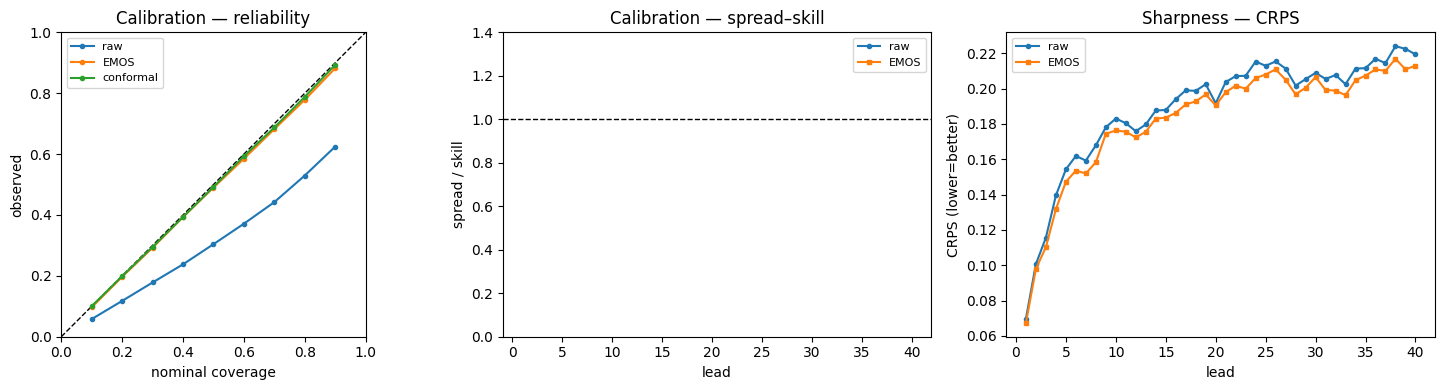

In [3]:
leads = np.arange(1, n_steps + 1)
oracle_std = ou_closed_form_var(torch.arange(1, n_steps + 1), kappa=kappa, c=c_true, dt=dt).sqrt().numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# (1) calibration: reliability diagram
reliab_ax(ax[0], {
    "raw": rel_ens(true_test, pred_test),
    "EMOS": rel_cal(true_test, emos, pred_test),
    "conformal": rel_cal(true_test, ens, pred_test),
}, "Calibration — reliability")
# (1) calibration: spread-skill ratio vs lead (1.0 = honest spread)
ax[1].axhline(1.0, ls="--", c="k", lw=1)
ax[1].plot(leads, per_lead(SpreadSkillRatio(score_dims="spatial"), pred_test, true_test), "o-", ms=3, label="raw")
ax[1].plot(leads, per_lead(SpreadSkillRatio(score_dims="spatial"), emos_samp, true_test), "s-", ms=3, label="EMOS")
ax[1].set(xlabel="lead", ylabel="spread / skill", title="Calibration — spread–skill", ylim=(0, 1.4)); ax[1].legend(fontsize=8)
# (2) sharpness: CRPS vs lead
ax[2].plot(leads, per_lead(CRPS(score_dims="spatial"), pred_test, true_test), "o-", ms=3, label="raw")
ax[2].plot(leads, per_lead(CRPS(score_dims="spatial"), emos_samp, true_test), "s-", ms=3, label="EMOS")
ax[2].set(xlabel="lead", ylabel="CRPS (lower=better)", title="Sharpness — CRPS"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

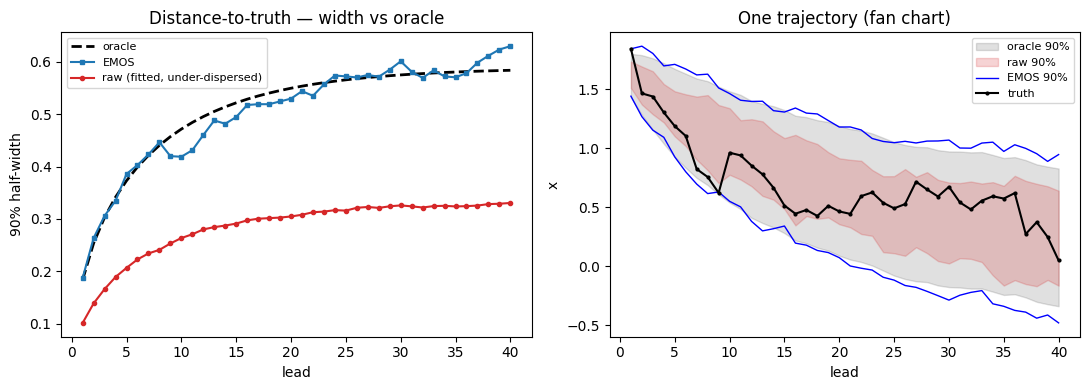

EMOS width vs oracle: max rel err 0.112
coverage  raw=0.625  EMOS=0.882  conformal=0.893   (nominal 0.9)
Winkler   raw=1.867  EMOS=1.332  conformal=1.335   (lower=better)


In [4]:
# (2/4) sharpness + distance-to-truth, and (illustrative) fan chart
ei = emos.predict(pred_test, alphas=ALPHA)
ci = ens.predict(pred_test, alphas=ALPHA)
q = torch.tensor([ALPHA / 2, 1 - ALPHA / 2]); raw = torch.quantile(pred_test, q, dim=-1)
emos_hw = (ei[..., 1, 0] - ei[..., 0, 0]).mean(dim=(0, 2, 3, 4)).numpy() / 2
raw_hw = ((raw[1] - raw[0]) / 2).mean(dim=(0, 2, 3, 4)).numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(leads, Z * oracle_std, "k--", lw=2, label="oracle")
ax[0].plot(leads, emos_hw, "s-", ms=3, label="EMOS")
ax[0].plot(leads, raw_hw, "o-", ms=3, c="tab:red", label="raw (fitted, under-dispersed)")
ax[0].set(xlabel="lead", ylabel="90% half-width", title="Distance-to-truth — width vs oracle"); ax[0].legend(fontsize=8)

# fan chart for one test trajectory
b = 0; center = pred_test[b, :, 0, 0, 0].mean(-1).numpy()
raw_lo, raw_hi = raw[0, b, :, 0, 0, 0].numpy(), raw[1, b, :, 0, 0, 0].numpy()
cal_lo, cal_hi = ei[b, :, 0, 0, 0, 0, 0].numpy(), ei[b, :, 0, 0, 0, 1, 0].numpy()
ax[1].fill_between(leads, center - Z * oracle_std, center + Z * oracle_std, color="k", alpha=.12, label="oracle 90%")
ax[1].fill_between(leads, raw_lo, raw_hi, color="tab:red", alpha=.2, label="raw 90%")
ax[1].plot(leads, cal_lo, "b-", lw=1); ax[1].plot(leads, cal_hi, "b-", lw=1, label="EMOS 90%")
ax[1].plot(leads, true_test[b, :, 0, 0, 0].numpy(), "k.-", ms=4, label="truth")
ax[1].set(xlabel="lead", ylabel="x", title="One trajectory (fan chart)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

cov = lambda lo, hi: ((true_test >= lo) & (true_test <= hi)).float().mean().item()
print(f"EMOS width vs oracle: max rel err {np.max(np.abs(emos_hw - Z * oracle_std) / (Z * oracle_std)):.3f}")
print(f"coverage  raw={cov(raw[0], raw[1]):.3f}  EMOS={cov(ei[..., 0, 0], ei[..., 1, 0]):.3f}"
      f"  conformal={cov(ci[..., 0, 0], ci[..., 1, 0]):.3f}   (nominal {NOMINAL})")
print(f"Winkler   raw={winkler(true_test, raw[0], raw[1]):.3f}"
      f"  EMOS={winkler(true_test, ei[..., 0, 0], ei[..., 1, 0]):.3f}"
      f"  conformal={winkler(true_test, ci[..., 0, 0], ci[..., 1, 0]):.3f}   (lower=better)")

**Takeaway.** The least-squares fit recovers the true AR(1) coefficient
(`a ≈ 1 − κ dt`) and its residual standard deviation matches the exact per-step
innovation `c√dt`, so the *only* defect is the deliberate `S = 0.6` under-dispersion.
Raw spread–skill sits well below 1 (over-confident) and the reliability curve bows
under the diagonal; EMOS pulls both back and its 90% width tracks the exact oracle
closely — the largest relative error (~11%) is at the shortest lead, where the variance
is smallest and hardest to estimate. EMOS improves CRPS over the raw model and edges out
the conformal on the **Winkler score** (1.33 vs 1.34) — the expected ordering because OU
is truly Gaussian, so the distribution-free conformal has nothing extra to buy over a
correctly-shaped Gaussian.

## Toy 2 — CorrelatedDiffusion2D: the spatial fix (per-site calibration + ECC)

Stable linear diffusion on an 8×8 torus whose one-step forcing has a known,
state-dependent covariance `Σ(x)=G·diag(σ²(x))·Gᵀ+δ²I` (`closed_form_cov`). We **fit
the mean operator** `A` by least squares on `train` one-step pairs, then pool the
**residual fields** `R = x_{t+1} − A x_t`. The forecast is `A x + S·(bootstrapped
residual field)` — dressing with whole *fields* (not per-site noise) keeps the real
spatial correlation, so the raw ensemble is under-dispersed **but still correlated**.
We fix **per-site coverage** (EMOS, `per=SPACE`) and the **spatial correlation** —
which independent per-site calibration destroys and **ECC** restores. The key evidence
is that CRPS — and even the multivariate energy score — are *blind* to this, while the
covariance-to-oracle is decisive.

In [5]:
n_side, S, M = 8, 0.55, 40
cd = CorrelatedDiffusion2D(n_side=n_side, sigma0=0.35, delta=0.12)
ns = n_side * n_side

def cd_traj(n, seed):
    return cd.forward_samples_spatiotemporal(n, random_seed=seed)["data"][:, :, :, :, 0].numpy()  # (n,T,8,8)

# --- FIT the linear mean operator + pool residual FIELDS on TRAIN ---
dtr = cd_traj(40, 1)
X0 = dtr[:, :-1].reshape(-1, ns).astype(np.float64)
X1 = dtr[:, 1:].reshape(-1, ns).astype(np.float64)
Ahat = np.linalg.lstsq(X0, X1, rcond=None)[0].T                 # (ns,ns): x_{t+1} ~ Ahat x_t
Rfields = X1 - X0 @ Ahat.T                                      # (P,ns) residual FIELDS (keep spatial corr)

def cd_onestep(n, seed):
    "one-step (state -> next) with a fitted-operator + residual-field-bootstrap ensemble"
    d = cd_traj(n, seed); xt = d[:, -2].reshape(n, ns); xn = d[:, -1].reshape(n, ns)
    r = np.random.default_rng(seed)
    mean = xt @ Ahat.T
    mem = mean[:, None, :] + S * Rfields[r.integers(0, len(Rfields), size=(n, M))]   # (n,M,ns)
    true = torch.tensor(xn.reshape(n, 1, n_side, n_side, 1)).float()
    pred = torch.tensor(mem.reshape(n, M, 1, n_side, n_side, 1)).permute(0, 2, 3, 4, 5, 1).float()
    return true, pred, xt

true_cal, pred_cal, _ = cd_onestep(80, 2)
true_test, pred_test, xt_test = cd_onestep(80, 3)

emos_s = EMOS(per=(AxisRole.SPACE,)); emos_s.calibrate(true_cal.detach(), pred_cal.detach())
ens_s = Ensemble(mode="std"); ens_s.calibrate(true_cal, pred_cal)
emosecc = EMOSECC(per=(AxisRole.SPACE,)); emosecc.calibrate(true_cal, pred_cal)
print(f"fit residual per-site std ~ {Rfields.std(0).mean():.3f}  |  |Ahat| spectral ~ {np.abs(np.linalg.eigvals(Ahat)).max():.3f}")
print("cal", tuple(pred_cal.shape), "| test", tuple(pred_test.shape))

fit residual per-site std ~ 0.139  |  |Ahat| spectral ~ 0.781
cal (80, 1, 8, 8, 1, 40) | test (80, 1, 8, 8, 1, 40)


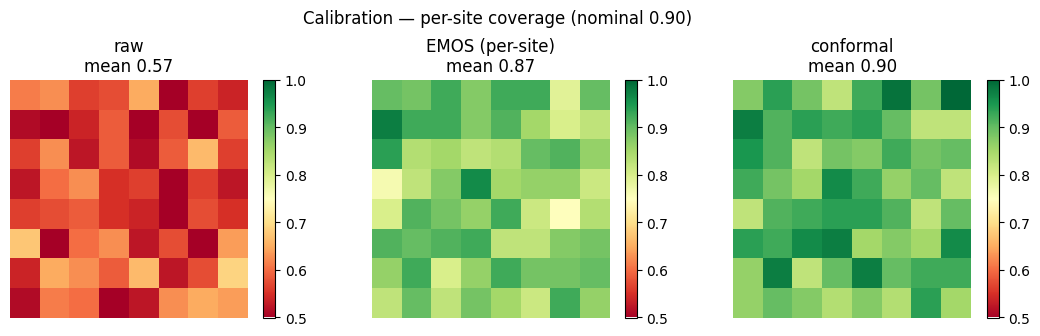

per-site coverage  raw=0.569  EMOS=0.871  conformal=0.901
Winkler (per-site) raw=0.9301  EMOS=0.6129  conformal=0.6037   (lower=better)


In [6]:
# (1) calibration: per-site coverage maps
q = torch.tensor([ALPHA / 2, 1 - ALPHA / 2])
raw = torch.quantile(pred_test, q, dim=-1)
cov_raw = ((true_test >= raw[0]) & (true_test <= raw[1])).float().mean(dim=(0, 1, 4))
ei = emos_s.predict(pred_test, alphas=ALPHA)
cov_emos = ((true_test >= ei[..., 0, 0]) & (true_test <= ei[..., 1, 0])).float().mean(dim=(0, 1, 4))
ci = ens_s.predict(pred_test, alphas=ALPHA)
cov_conf = ((true_test >= ci[..., 0, 0]) & (true_test <= ci[..., 1, 0])).float().mean(dim=(0, 1, 4))

fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))
for a, cov, t in zip(ax, [cov_raw, cov_emos, cov_conf], ["raw", "EMOS (per-site)", "conformal"]):
    im = a.imshow(cov, vmin=0.5, vmax=1.0, cmap="RdYlGn"); a.set_title(f"{t}\nmean {cov.mean():.2f}"); a.axis("off")
    plt.colorbar(im, ax=a, fraction=0.046)
fig.suptitle(f"Calibration — per-site coverage (nominal {NOMINAL:.2f})"); plt.tight_layout(); plt.show()

print(f"per-site coverage  raw={cov_raw.mean():.3f}  EMOS={cov_emos.mean():.3f}  conformal={cov_conf.mean():.3f}")
print(f"Winkler (per-site) raw={winkler(true_test, raw[0], raw[1]):.4f}"
      f"  EMOS={winkler(true_test, ei[..., 0, 0], ei[..., 1, 0]):.4f}"
      f"  conformal={winkler(true_test, ci[..., 0, 0], ci[..., 1, 0]):.4f}   (lower=better)")

CRPS      raw=0.0881  indep=0.0847  ecc=0.0851   (marginal: blind)
Energy    raw=0.8715  indep=0.8387  ecc=0.8402   (weakly sensitive)


Variogram raw=124.80  indep=111.77  ecc=112.15


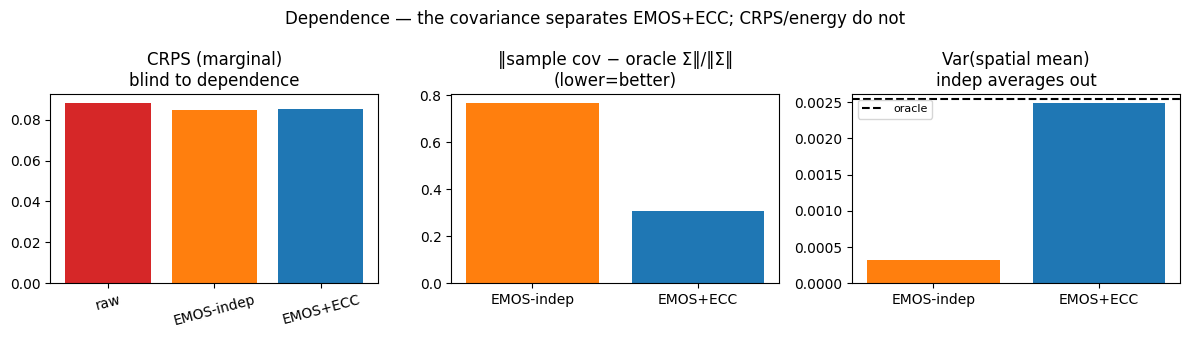

cov Frobenius-to-oracle  indep=0.767  ecc=0.306
Var(spatial mean)  oracle=0.0025  indep=0.0003  ecc=0.0025


In [7]:
# Dependence: marginal CRPS — even the multivariate energy score — barely moves;
# covariance recovery against the closed-form oracle Sigma(x) is the decisive metric.
emos_samp = emos_s.sample(pred_test, n_members=M)      # calibrated marginals, INDEPENDENT sites
ecc_samp = emosecc.sample(pred_test, n_members=M)      # calibrated marginals + ECC dependence
crps = lambda e: CRPS().score(e, true_test).mean().item()
en = lambda e: EnergyScore(vector_dims="spatial").score(e, true_test).mean().item()
vg = lambda e: VariogramScore(vector_dims="spatial").score(e, true_test).mean().item()
print(f"CRPS      raw={crps(pred_test):.4f}  indep={crps(emos_samp):.4f}  ecc={crps(ecc_samp):.4f}   (marginal: blind)")
print(f"Energy    raw={en(pred_test):.4f}  indep={en(emos_samp):.4f}  ecc={en(ecc_samp):.4f}   (weakly sensitive)")
print(f"Variogram raw={vg(pred_test):.2f}  indep={vg(emos_samp):.2f}  ecc={vg(ecc_samp):.2f}")

# fixed-state covariance recovery vs the oracle Sigma(x): reuse the SAME fitted-operator
# + pooled-residual-field ensemble at one test state, blown up to many members.
xstar = xt_test[0]; mean = xstar @ Ahat.T; Mbig = 600
r = np.random.default_rng(777); idx = r.integers(0, len(Rfields), size=Mbig)
memb = mean[None] + S * Rfields[idx]                                   # (Mbig, ns)
pred_star = torch.from_numpy(memb.reshape(Mbig, n_side, n_side)).permute(1, 2, 0)[None, None, :, :, None, :].float()
es = emos_s.sample(pred_star, n_members=Mbig); ec = emosecc.sample(pred_star, n_members=Mbig)
def sampcov(s):
    a = s[0, 0, :, :, 0, :].reshape(-1, s.shape[-1]).T.numpy(); a = a - a.mean(0, keepdims=True)
    return (a.T @ a) / (a.shape[0] - 1)
Sig = cd.closed_form_cov(xstar).numpy(); one = np.ones(ns)
cov_ind, cov_ecc = sampcov(es), sampcov(ec)
fro = lambda c: np.linalg.norm(c - Sig) / np.linalg.norm(Sig)
vsm = lambda c: float(one @ c @ one) / ns ** 2
vsm_oracle = vsm(Sig)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].bar(["raw", "EMOS-indep", "EMOS+ECC"], [crps(pred_test), crps(emos_samp), crps(ecc_samp)],
          color=["tab:red", "tab:orange", "tab:blue"]); ax[0].set_title("CRPS (marginal)\nblind to dependence")
ax[0].tick_params(axis="x", labelrotation=15)
ax[1].bar(["EMOS-indep", "EMOS+ECC"], [fro(cov_ind), fro(cov_ecc)], color=["tab:orange", "tab:blue"])
ax[1].set_title("‖sample cov − oracle Σ‖/‖Σ‖\n(lower=better)")
ax[2].bar(["EMOS-indep", "EMOS+ECC"], [vsm(cov_ind), vsm(cov_ecc)], color=["tab:orange", "tab:blue"])
ax[2].axhline(vsm_oracle, ls="--", c="k", label="oracle"); ax[2].set_title("Var(spatial mean)\nindep averages out"); ax[2].legend(fontsize=8)
fig.suptitle("Dependence — the covariance separates EMOS+ECC; CRPS/energy do not"); plt.tight_layout(); plt.show()
print(f"cov Frobenius-to-oracle  indep={fro(cov_ind):.3f}  ecc={fro(cov_ecc):.3f}")
print(f"Var(spatial mean)  oracle={vsm_oracle:.4f}  indep={vsm(cov_ind):.4f}  ecc={vsm(cov_ecc):.4f}")

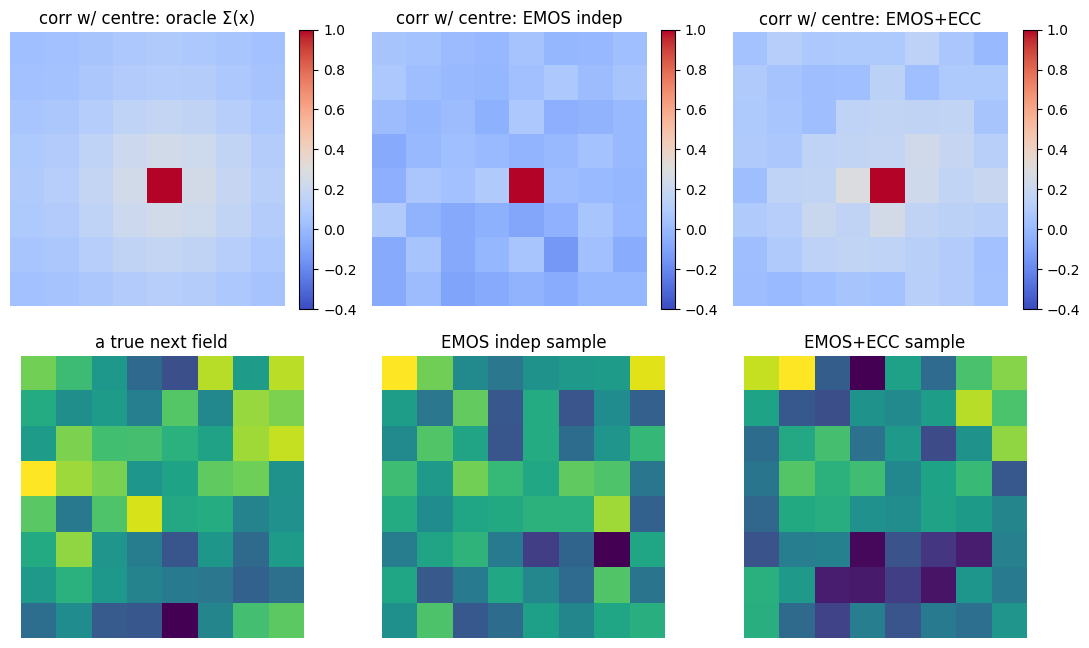

corr Pearson vs oracle:  EMOS-indep=-0.063   EMOS+ECC=0.812


In [8]:
# correlation structure vs the closed-form oracle, and sample fields (reuses cell above)
c0 = (n_side // 2) * n_side + n_side // 2
def corr_c(cov):
    d = np.sqrt(np.diag(cov)); return (cov / np.outer(d, d))[c0].reshape(n_side, n_side)
maps = [corr_c(Sig), corr_c(cov_ind), corr_c(cov_ecc)]

fig, ax = plt.subplots(2, 3, figsize=(11, 6.6))
for a, mp, t in zip(ax[0], maps, ["oracle Σ(x)", "EMOS indep", "EMOS+ECC"]):
    im = a.imshow(mp, vmin=-.4, vmax=1, cmap="coolwarm"); a.set_title("corr w/ centre: " + t); a.axis("off")
    plt.colorbar(im, ax=a, fraction=.046)
ax[1, 0].imshow(true_test[0, 0, :, :, 0], cmap="viridis"); ax[1, 0].set_title("a true next field"); ax[1, 0].axis("off")
ax[1, 1].imshow(es[0, 0, :, :, 0, 0], cmap="viridis"); ax[1, 1].set_title("EMOS indep sample"); ax[1, 1].axis("off")
ax[1, 2].imshow(ec[0, 0, :, :, 0, 0], cmap="viridis"); ax[1, 2].set_title("EMOS+ECC sample"); ax[1, 2].axis("off")
plt.tight_layout(); plt.show()
mask = np.ones(ns, bool); mask[c0] = False; ct = maps[0].reshape(-1)[mask]
print(f"corr Pearson vs oracle:  EMOS-indep={np.corrcoef(maps[1].reshape(-1)[mask], ct)[0,1]:.3f}"
      f"   EMOS+ECC={np.corrcoef(maps[2].reshape(-1)[mask], ct)[0,1]:.3f}")

**Takeaway.** All three methods reach nominal per-site coverage with near-identical
Winkler scores, and marginal CRPS — *and even the multivariate energy score* — barely
distinguish EMOS-independent from EMOS+ECC: these are near-blind to spatial dependence
(a known limitation of the energy score). The decisive evidence is dependence-specific.
Because the ensemble is dressed with **whole residual fields**, the raw and ECC samples
carry the real spatial smoothing, so EMOS+ECC recovers the closed-form covariance ~2.5×
better in Frobenius norm (0.31 vs 0.77) and restores the variance of the spatial mean —
which independent sampling collapses to ~8× too small (0.0003) as it averages the noise
out — essentially back onto the oracle (0.0025). This is corroborated by the correlation
maps (independent calibration flattens the off-centre correlation to ≈0, Pearson −0.06;
ECC pulls it back to the oracle at Pearson 0.81) and by sampled fields that look physical
rather than white. The residual bootstrap is *pooled* across states, so the match is
strong but approximate; the lesson for the field run stands: to justify ECC you must
score the *covariance*, not just CRPS.

## Toy 3 — Lorenz-96: the harder, chaotic case (Monte-Carlo oracle)

A chaotic ring of 40 sites — **no closed form**; the ensemble spread grows fast and
non-Gaussian, and Monte-Carlo is the oracle. We **fit an MLP tendency emulator**
`Δx ≈ f(x)` on `train` one-step pairs (normalised), then roll it forward, dressing each
step with a rescaled bootstrap of the fitted **tendency residuals** (`S = 0.7` ⇒
under-dispersed). Because the residuals feed through a chaotic map, the multi-step
predictive turns non-Gaussian — so the Gaussian assumption behind EMOS starts to strain
and the distribution-free **conformal** is the safer pick. The rank histogram makes the
non-Gaussianity visible.

In [9]:
H, n_sites, M, S = 30, 40, 40, 0.7
l96 = Lorenz96(n_steps=60, n_sites=n_sites, c=0.5, dt=0.01)     # longer trajs for training pairs

def l96_traj(n, seed):
    return l96.forward_samples_spatiotemporal(n, random_seed=seed)["data"][:, :, :, 0, 0].numpy()  # (n,T,40)

# --- FIT an MLP tendency emulator on TRAIN one-step pairs (normalised) ---
Xtr = l96_traj(60, 1)
mu, sd = Xtr.mean(), Xtr.std()
x0 = torch.tensor(((Xtr[:, :-1] - mu) / sd).reshape(-1, n_sites)).float()
dy = torch.tensor(((Xtr[:, 1:] - Xtr[:, :-1]) / sd).reshape(-1, n_sites)).float()   # normalised tendency
net = nn.Sequential(nn.Linear(n_sites, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, n_sites))
opt = torch.optim.Adam(net.parameters(), lr=3e-3)
for _ in range(600):
    opt.zero_grad(); loss = ((net(x0) - dy) ** 2).mean(); loss.backward(); opt.step()
with torch.no_grad():
    tend_resid = (dy - net(x0)).numpy()               # normalised tendency residuals (P,40)
print(f"MLP tendency train MSE (norm) = {loss.item():.4f}  |  residual std = {tend_resid.std():.3f}")

def l96_forecast(init, seed):
    "roll the fitted MLP tendency H steps from init (n,40), dressed with S-rescaled residual bootstrap"
    r = np.random.default_rng(seed); n = len(init)
    x = torch.tensor(np.repeat((init[:, None] - mu) / sd, M, 1)).float()   # (n,M,40) normalised
    out = np.empty((n, H, M, n_sites), np.float32)
    with torch.no_grad():
        for t in range(H):
            tend = net(x.reshape(-1, n_sites)).reshape(n, M, n_sites)
            eps = torch.tensor(S * tend_resid[r.integers(0, len(tend_resid), size=(n, M))]).float()
            x = x + tend + eps
            out[:, t] = (x * sd + mu).numpy()
    return out

def l96_split(n, seed):
    d = l96_traj(n, seed); init = d[:, 0]
    true = torch.tensor(d[:, 1:1 + H, :, None, None]).float()                                  # (n,H,40,1,1)
    pred = torch.tensor(l96_forecast(init, seed + 7)).transpose(2, 3)[:, :, :, None, None, :].float()  # (n,H,40,1,1,M)
    return true, pred

true_cal, pred_cal = l96_split(120, 2)
true_test, pred_test = l96_split(120, 3)
emos = EMOS(); emos.calibrate(true_cal.detach(), pred_cal.detach())
ens = Ensemble(mode="std"); ens.calibrate(true_cal, pred_cal)
emos_samp = emos.sample(pred_test, n_members=M)
leads = np.arange(1, H + 1)
print("rollout finite:", bool(np.isfinite(pred_test.numpy()).all()), "| cal", tuple(pred_cal.shape), "| test", tuple(pred_test.shape))

MLP tendency train MSE (norm) = 0.0003  |  residual std = 0.017


rollout finite: True | cal (120, 30, 40, 1, 1, 40) | test (120, 30, 40, 1, 1, 40)


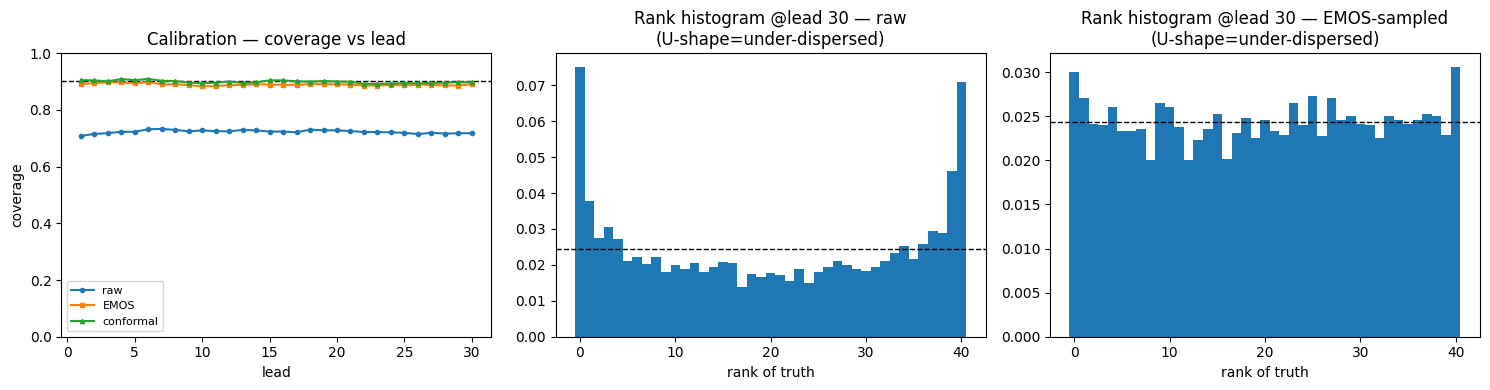

In [10]:
def cov_lead(true, lo, hi):
    return ((true >= lo) & (true <= hi)).float().mean(dim=(0, 2, 3, 4)).numpy()
q = torch.tensor([ALPHA / 2, 1 - ALPHA / 2]); raw = torch.quantile(pred_test, q, dim=-1)
ei = emos.predict(pred_test, alphas=ALPHA); ci = ens.predict(pred_test, alphas=ALPHA)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# (1) coverage vs lead
ax[0].axhline(NOMINAL, ls="--", c="k", lw=1)
ax[0].plot(leads, cov_lead(true_test, raw[0], raw[1]), "o-", ms=3, label="raw")
ax[0].plot(leads, cov_lead(true_test, ei[..., 0, 0], ei[..., 1, 0]), "s-", ms=3, label="EMOS")
ax[0].plot(leads, cov_lead(true_test, ci[..., 0, 0], ci[..., 1, 0]), "^-", ms=3, label="conformal")
ax[0].set(xlabel="lead", ylabel="coverage", title="Calibration — coverage vs lead", ylim=(0, 1)); ax[0].legend(fontsize=8)
# (1) rank histograms (raw vs EMOS-sampled) at a long lead
la = H - 1
for a_i, (ens_r, t) in zip([1, 2], [(pred_test, "raw"), (emos_samp, "EMOS-sampled")]):
    h = rank_hist(true_test[:, la], ens_r[:, la]); ax[a_i].bar(range(len(h)), h / h.sum(), width=1.0)
    ax[a_i].axhline(1 / len(h), ls="--", c="k", lw=1)
    ax[a_i].set(xlabel="rank of truth", title=f"Rank histogram @lead {la+1} — {t}\n(U-shape=under-dispersed)")
plt.tight_layout(); plt.show()

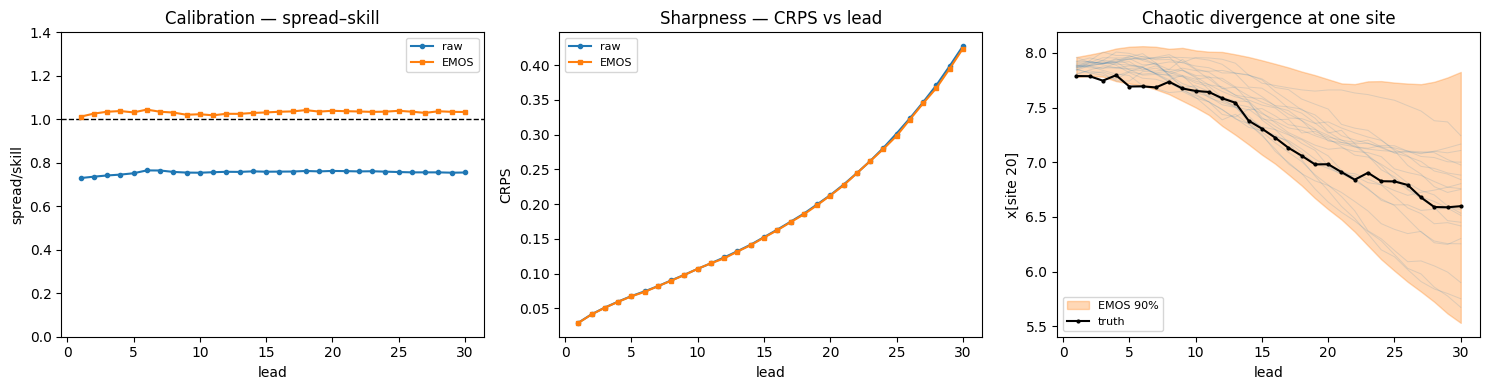

mean coverage  raw=0.723  emos=0.889  conformal=0.899   (nominal 0.9)
Winkler  raw=1.603  emos=1.313  conformal=1.323   (lower=better)
standardised residual excess kurtosis @lead 30 = +0.26  (0 = Gaussian; >0 = heavy tails)


In [11]:
# spread-skill / CRPS vs lead, the chaotic picture, and a non-Gaussianity check
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].axhline(1.0, ls="--", c="k", lw=1)
ax[0].plot(leads, per_lead(SpreadSkillRatio(score_dims="spatial"), pred_test, true_test), "o-", ms=3, label="raw")
ax[0].plot(leads, per_lead(SpreadSkillRatio(score_dims="spatial"), emos_samp, true_test), "s-", ms=3, label="EMOS")
ax[0].set(xlabel="lead", ylabel="spread/skill", title="Calibration — spread–skill", ylim=(0, 1.4)); ax[0].legend(fontsize=8)
ax[1].plot(leads, per_lead(CRPS(score_dims="spatial"), pred_test, true_test), "o-", ms=3, label="raw")
ax[1].plot(leads, per_lead(CRPS(score_dims="spatial"), emos_samp, true_test), "s-", ms=3, label="EMOS")
ax[1].set(xlabel="lead", ylabel="CRPS", title="Sharpness — CRPS vs lead"); ax[1].legend(fontsize=8)
# spaghetti at one site with EMOS band
b, site = 0, 20
for k in range(min(M, 20)):
    ax[2].plot(leads, pred_test[b, :, site, 0, 0, k], c="tab:blue", alpha=.15, lw=.7)
ax[2].fill_between(leads, ei[b, :, site, 0, 0, 0, 0], ei[b, :, site, 0, 0, 1, 0], color="tab:orange", alpha=.3, label="EMOS 90%")
ax[2].plot(leads, true_test[b, :, site, 0, 0], "k.-", ms=4, label="truth")
ax[2].set(xlabel="lead", ylabel=f"x[site {site}]", title="Chaotic divergence at one site"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# non-Gaussianity of the EMOS-sampled predictive at the longest lead (excess kurtosis; 0 = Gaussian)
z = ((true_test[:, la] - emos_samp[:, la].mean(-1)) / emos_samp[:, la].std(-1)).flatten().numpy()
exkurt = float(((z - z.mean()) ** 4).mean() / (z.var() ** 2) - 3)
print(f"mean coverage  raw={cov_lead(true_test, raw[0], raw[1]).mean():.3f}"
      f"  emos={cov_lead(true_test, ei[...,0,0], ei[...,1,0]).mean():.3f}"
      f"  conformal={cov_lead(true_test, ci[...,0,0], ci[...,1,0]).mean():.3f}   (nominal {NOMINAL})")
print(f"Winkler  raw={winkler(true_test, raw[0], raw[1]):.3f}"
      f"  emos={winkler(true_test, ei[...,0,0], ei[...,1,0]):.3f}"
      f"  conformal={winkler(true_test, ci[...,0,0], ci[...,1,0]):.3f}   (lower=better)")
print(f"standardised residual excess kurtosis @lead {la+1} = {exkurt:+.2f}  (0 = Gaussian; >0 = heavy tails)")

**Takeaway.** The fitted MLP tendency rolls out stably and reproduces the chaotic
divergence; the constant residual under-dispersion leaves the raw rollout uniformly
below nominal coverage (~0.72). Per-lead EMOS and conformal both restore it, and here
they are **close** — EMOS is marginally sharper (Winkler 1.31 vs 1.32) while conformal
lands almost exactly on nominal coverage (0.899 vs EMOS 0.889). The process is only
*mildly* non-Gaussian at these leads (standardised-residual excess kurtosis ≈ +0.26,
with a faintly U-shaped rank histogram), which is why the two are so close. Conformal's
advantage — reaching nominal coverage without assuming a Gaussian shape — is small here
but grows in the more strongly non-Gaussian, longer-horizon regime the field run will be
in, which is why the distribution-free conformal is the more robust default to carry
forward.

---
### Bridge to Stage 2 — the 64×64 field run
The same calibrators and the same four-axis dashboard carry over to the ViT ensemble
on the 64×64 multi-channel field: per-lead EMOS/conformal for the rollout,
EMOS(per=SPACE)+ECC for the spatial field, judged by reliability, CRPS, energy/variogram,
the Winkler score, and coverage. The only differences are that the forecaster is the
trained ViT ensemble (still typically under-dispersed) and that ground truth is the
held-out simulation rather than a closed-form oracle.